In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\numpy\.libs\libopenblas64__v0.3.23-246-g3d31191b-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])          


In [3]:
cifar100_train = CIFAR100(root='./data', train=True, download=True, transform=transform)
# cifar100_test = CIFAR100(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append(r'D:/mjthesis')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar100_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size -valid_size)

trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

40000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.0767020748615266,train_accu=0.68335
Epoch=0,valid_loss=1.413151455116272,valid_accu=0.5945
0
Epoch=1,train_loss=0.7446524958372116,train_accu=0.779625
Epoch=1,valid_loss=1.2532376038551332,valid_accu=0.6331
0
Epoch=2,train_loss=0.5543463475823402,train_accu=0.840525
Epoch=2,valid_loss=1.223712855911255,valid_accu=0.6536
0
Epoch=3,train_loss=0.40501441155672074,train_accu=0.886125
Epoch=3,valid_loss=1.1983333786964416,valid_accu=0.665
0
Epoch=4,train_loss=0.3168537543118,train_accu=0.908975
Epoch=4,valid_loss=1.219514791584015,valid_accu=0.6633
Epoch=5,train_loss=0.2266633361876011,train_accu=0.94305
Epoch=5,valid_loss=1.1971712230682372,valid_accu=0.6742
0
Epoch=6,train_loss=0.20661620129048824,train_accu=0.9444
Epoch=6,valid_loss=1.258559108543396,valid_accu=0.6661
Epoch=7,train_loss=0.19026823643743992,train_accu=0.953075
Epoch=7,valid_loss=1.2374991784095764,valid_accu=0.6667
Learning rate reduced by 10%9e-05
Epoch=8,train_loss=0.1438431574359536,train_accu=0.96

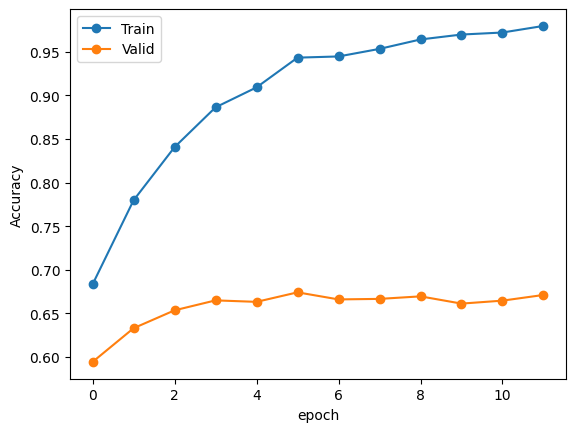

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_23.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.22666333718299866, 0.94305)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.1971711742401123, 0.6742)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu=each_accu.sort_values(ascending=True)
each_accu

pine_tree        0.778607
seal             0.802532
shrew            0.802920
orchid           0.822165
oak_tree         0.822785
                   ...   
house            0.995062
sunflower        0.997481
pickup_truck     1.000000
rose             1.000000
aquarium_fish    1.000000
Length: 100, dtype: float64

In [15]:
each_f1=2*p*r/(p+r)
each_f1

apple            0.960510
aquarium_fish    0.970803
baby             0.948298
bear             0.931373
beaver           0.917826
                   ...   
whale            0.935000
willow_tree      0.898263
wolf             0.961298
woman            0.925881
worm             0.933815
Length: 100, dtype: float64

In [16]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements[:N], top_positions[:N]

In [17]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=50)

Top 50 Elements:
[0.16237113 0.15892901 0.12435233 0.10688406 0.08671677 0.08232446
 0.07431382 0.06766917 0.06542815 0.05846572 0.05827965 0.05714268
 0.05670103 0.05545404 0.05472637 0.05432099 0.05289676 0.05225653
 0.05142095 0.04653182 0.04580153 0.04534602 0.04473954 0.04442468
 0.04264462 0.04242081 0.0423888  0.04116223 0.04060914 0.03767164
 0.03700099 0.03631961 0.03544304 0.03431373 0.03381643 0.03003198
 0.0297214  0.02921497 0.02771675 0.02725235 0.02722772 0.02663438
 0.02583979 0.0247479  0.02459864 0.02437306 0.02330271 0.02290193
 0.0225     0.02233251]
Top 50 Positions:
[(70, 54), (52, 47), (92, 70), (61, 10), (71, 60), (37, 17), (50, 36), (81, 13), (67, 32), (98, 35), (72, 55), (96, 47), (70, 62), (73, 67), (96, 59), (83, 57), (24, 7), (95, 73), (73, 30), (61, 22), (40, 28), (95, 30), (59, 47), (35, 11), (71, 23), (59, 52), (11, 2), (37, 12), (44, 27), (96, 52), (45, 26), (97, 42), (73, 72), (55, 4), (79, 26), (25, 5), (99, 78), (74, 4), (49, 23), (71, 49), (21, 3), 

In [18]:
unique_elements = set()

# 遍历所有的元组，并将每个元素添加到集合中
for pair in top_positions:
    unique_elements.update(pair)

unique_list = list(unique_elements)

print(len(unique_list))    

59


In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',40)

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.dataset.classess)]
    targetF=unique_list
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(23639, 16361)

In [20]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(5861, 4139)

In [21]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [22]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [23]:
# class_counts = [0, 0]
# for _,_,label,_ in trainset:
#     class_counts[label] +=1

In [24]:
# # 计算每个类别的权重
# class_weights = [1.0 / count for count in class_counts]
# weights = torch.FloatTensor(class_weights).cuda()

In [25]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)

    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    elif(data_name=='0'):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-2)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    else:   

        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.11119476083666086,train_accu=0.96695
Epoch=0,valid_loss=0.29449722690582275,valid_accu=0.8719
0
Epoch=1,train_loss=0.05650848708599806,train_accu=0.987075
Epoch=1,valid_loss=0.30124949510097504,valid_accu=0.8801
0
Epoch=2,train_loss=0.027788740764930844,train_accu=0.9951
Epoch=2,valid_loss=0.3304172961652279,valid_accu=0.8837
0
Epoch=3,train_loss=0.01662289072209969,train_accu=0.996425
Epoch=3,valid_loss=0.36243118199706076,valid_accu=0.8853
0
Epoch=4,train_loss=0.012619066328229383,train_accu=0.997725
Epoch=4,valid_loss=0.3896719687461853,valid_accu=0.8813
Epoch=5,train_loss=0.00698476150368806,train_accu=0.999225
Epoch=5,valid_loss=0.38470888661146163,valid_accu=0.8873
0
Epoch=6,train_loss=0.007017502798512578,train_accu=0.99885
Epoch=6,valid_loss=0.42135954527258873,valid_accu=0.884
Epoch=7,train_loss=0.005937574477260932,train_accu=0.998775
Epoch=7,valid_loss=0.45185876493006943,valid_accu=0.8838
Learning rate reduced by 10%9e-05
Epoch=8,train_loss=0.0039721221

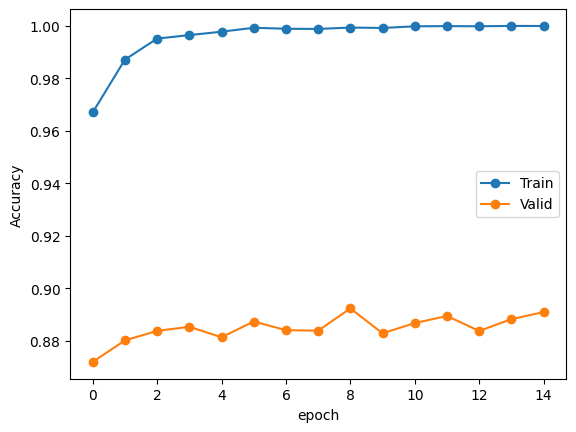

In [26]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [27]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.05751881568970012,train_accu=0.9876535664079212
Epoch=0,valid_loss=0.638402001182075,valid_accu=0.8151727470403479
0
Epoch=1,train_loss=0.028513191003040693,train_accu=0.993765662245584
Epoch=1,valid_loss=0.6983966335175434,valid_accu=0.8113070790045904
Epoch=2,train_loss=0.018296539593183097,train_accu=0.9956604119552595
Epoch=2,valid_loss=0.7548511735365915,valid_accu=0.8166223725537569
0
Epoch=3,train_loss=0.008332241175638307,train_accu=0.9985942179573376
Epoch=3,valid_loss=0.768232903191939,valid_accu=0.8204880405895144
0
Epoch=4,train_loss=0.008436594235840983,train_accu=0.9981052502903246
Epoch=4,valid_loss=0.8360967541063543,valid_accu=0.8122734960135298
Epoch=5,train_loss=0.00559680498714646,train_accu=0.9988387017908441
Epoch=5,valid_loss=0.8089649865854245,valid_accu=0.8238705001208021
0
Epoch=6,train_loss=0.003062761670587394,train_accu=0.9993276694578571
Epoch=6,valid_loss=0.8512975818784262,valid_accu=0.8243537086252718
0
Epoch=7,train_loss=0.02039412

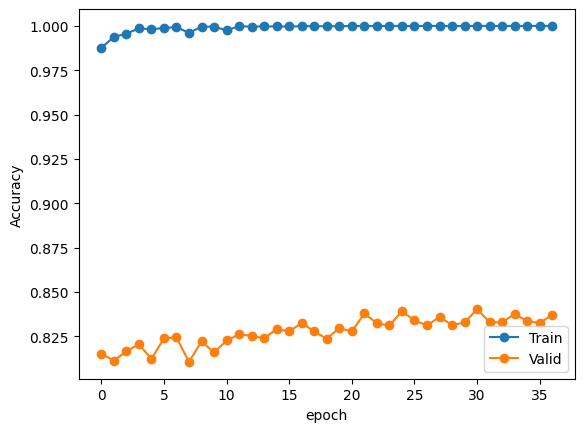

In [28]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.19791828204146336,train_accu=0.9469097677566733
Epoch=0,valid_loss=1.1218114018419907,valid_accu=0.6753113803105272
0
Epoch=1,train_loss=0.10025354528584463,train_accu=0.97466051863446
Epoch=1,valid_loss=1.2009977439303707,valid_accu=0.6763350963999317
0
Epoch=2,train_loss=0.05454285886155855,train_accu=0.9879013494648674
Epoch=2,valid_loss=1.2364801508313334,valid_accu=0.684354205766934
0
Epoch=3,train_loss=0.048178952925612896,train_accu=0.987647531621473
Epoch=3,valid_loss=1.3396748172771074,valid_accu=0.6800887220610817
Epoch=4,train_loss=0.024556083030983892,train_accu=0.9944160074453234
Epoch=4,valid_loss=1.3403492382495725,valid_accu=0.6990274697150657
0
Epoch=5,train_loss=0.022604013241149374,train_accu=0.9946698252887178
Epoch=5,valid_loss=1.4384486499173998,valid_accu=0.6870841153386794
Epoch=6,train_loss=0.021286622933542897,train_accu=0.9945006133931216
Epoch=6,valid_loss=1.48187824724742,valid_accu=0.6812830574987203
Learning rate reduced by 10%9e-05
E

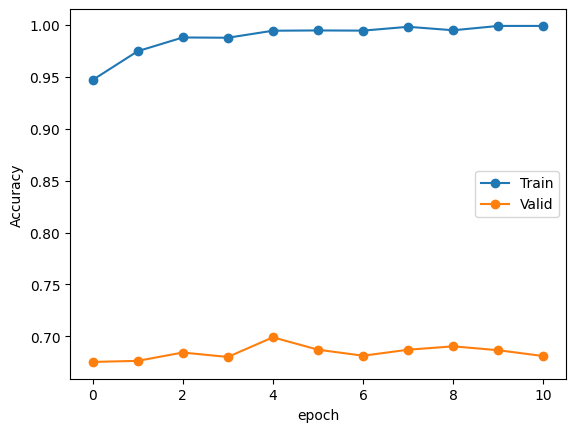

In [29]:
#訓練模型T、F、decision
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
# model_F=torch.load(f'model_{model_algo}_F_1.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.003972122259484604, 0.9993)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.4540113577991724, 0.8923)

In [32]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(7.471073461464359e-06, 1.0)

In [33]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.024556083004232846, 0.9944160074453234)

In [34]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.0852211765921556, 0.8402995892727712)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.340349142125515, 0.6990274697150657)

In [36]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.014515279101219494, 0.9967, 23639)

In [37]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.2347536706447602, 0.7575, 5861)

In [38]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t in zip(data,target):
                
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                out=model_0(d.unsqueeze(0))
                _, pred_0= torch.max(out, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_d<0.9):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [39]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(0.04018281017290428, 0.996, 23615, 16385)

In [40]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(3.318670089530945, 0.6964, 5832, 4168)

In [41]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [42]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classaccu', [0, 2, 3, 4, 5, 7, 10, 11, 12, 13, 17, 21, 22, 23, 24, 25, 26, 27, 28, 30, 32, 33, 35, 36, 37, 40, 42, 44, 45, 46, 47, 49, 50, 52, 54, 55, 57, 59, 60, 61, 62, 67, 70, 71, 72, 73, 74, 78, 79, 81, 83, 90, 92, 93, 95, 96, 97, 98, 99])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.226663,0.943050,1.197171,0.674200
1,Model_Decision,0.003972,0.999300,0.454011,0.892300
2,Model_T,0.000007,1.000000,1.085221,0.840300
3,Model_F,0.024556,0.994416,1.340349,0.699027
4,Total_Model,0.040183,0.996000,3.318670,0.696400
5,Total_Model_with_perfect_decision,0.014515,0.996700,1.234754,0.757500


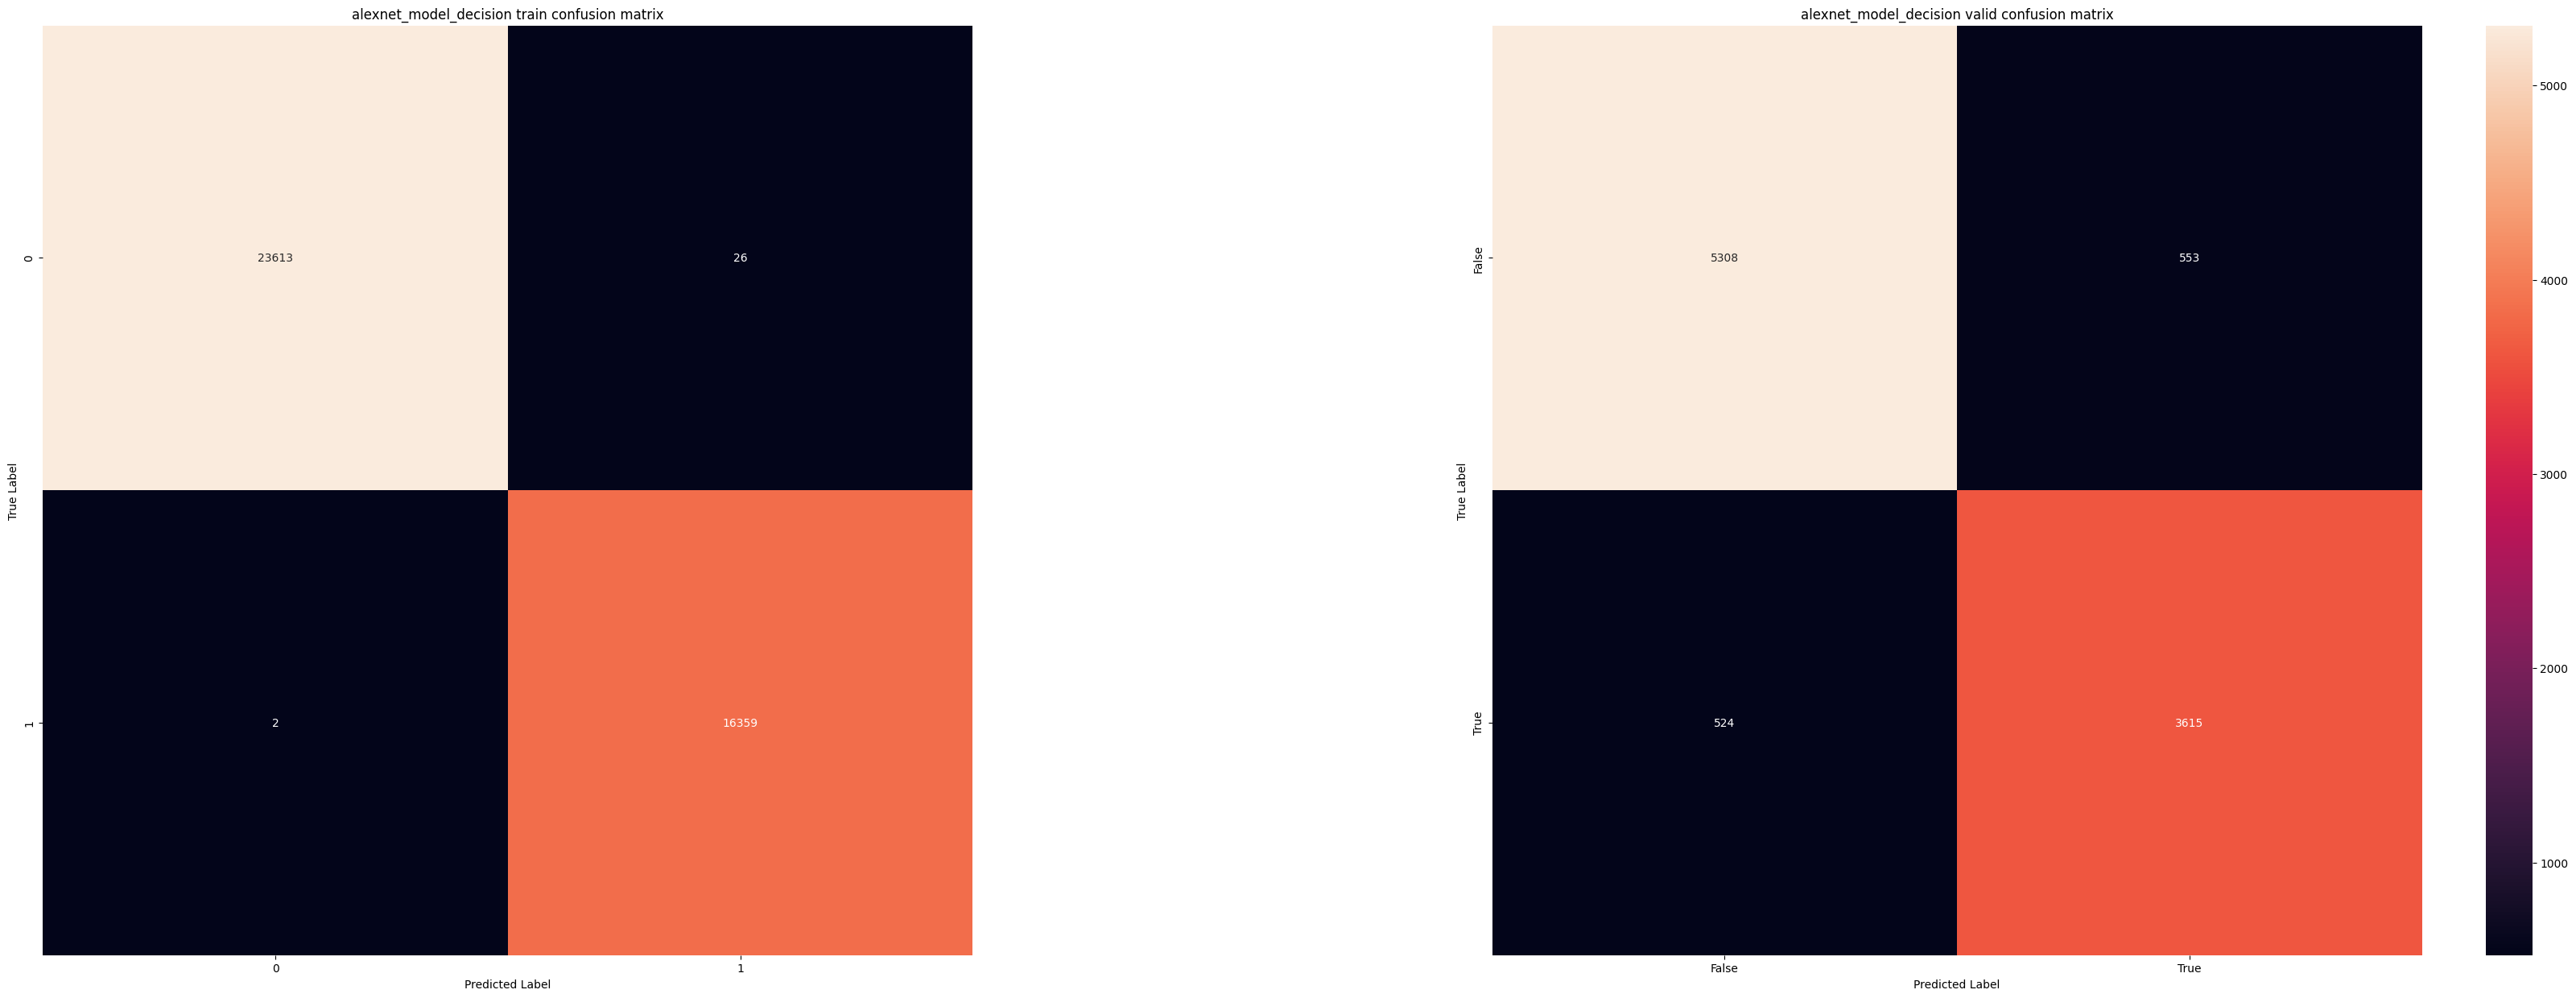

In [43]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

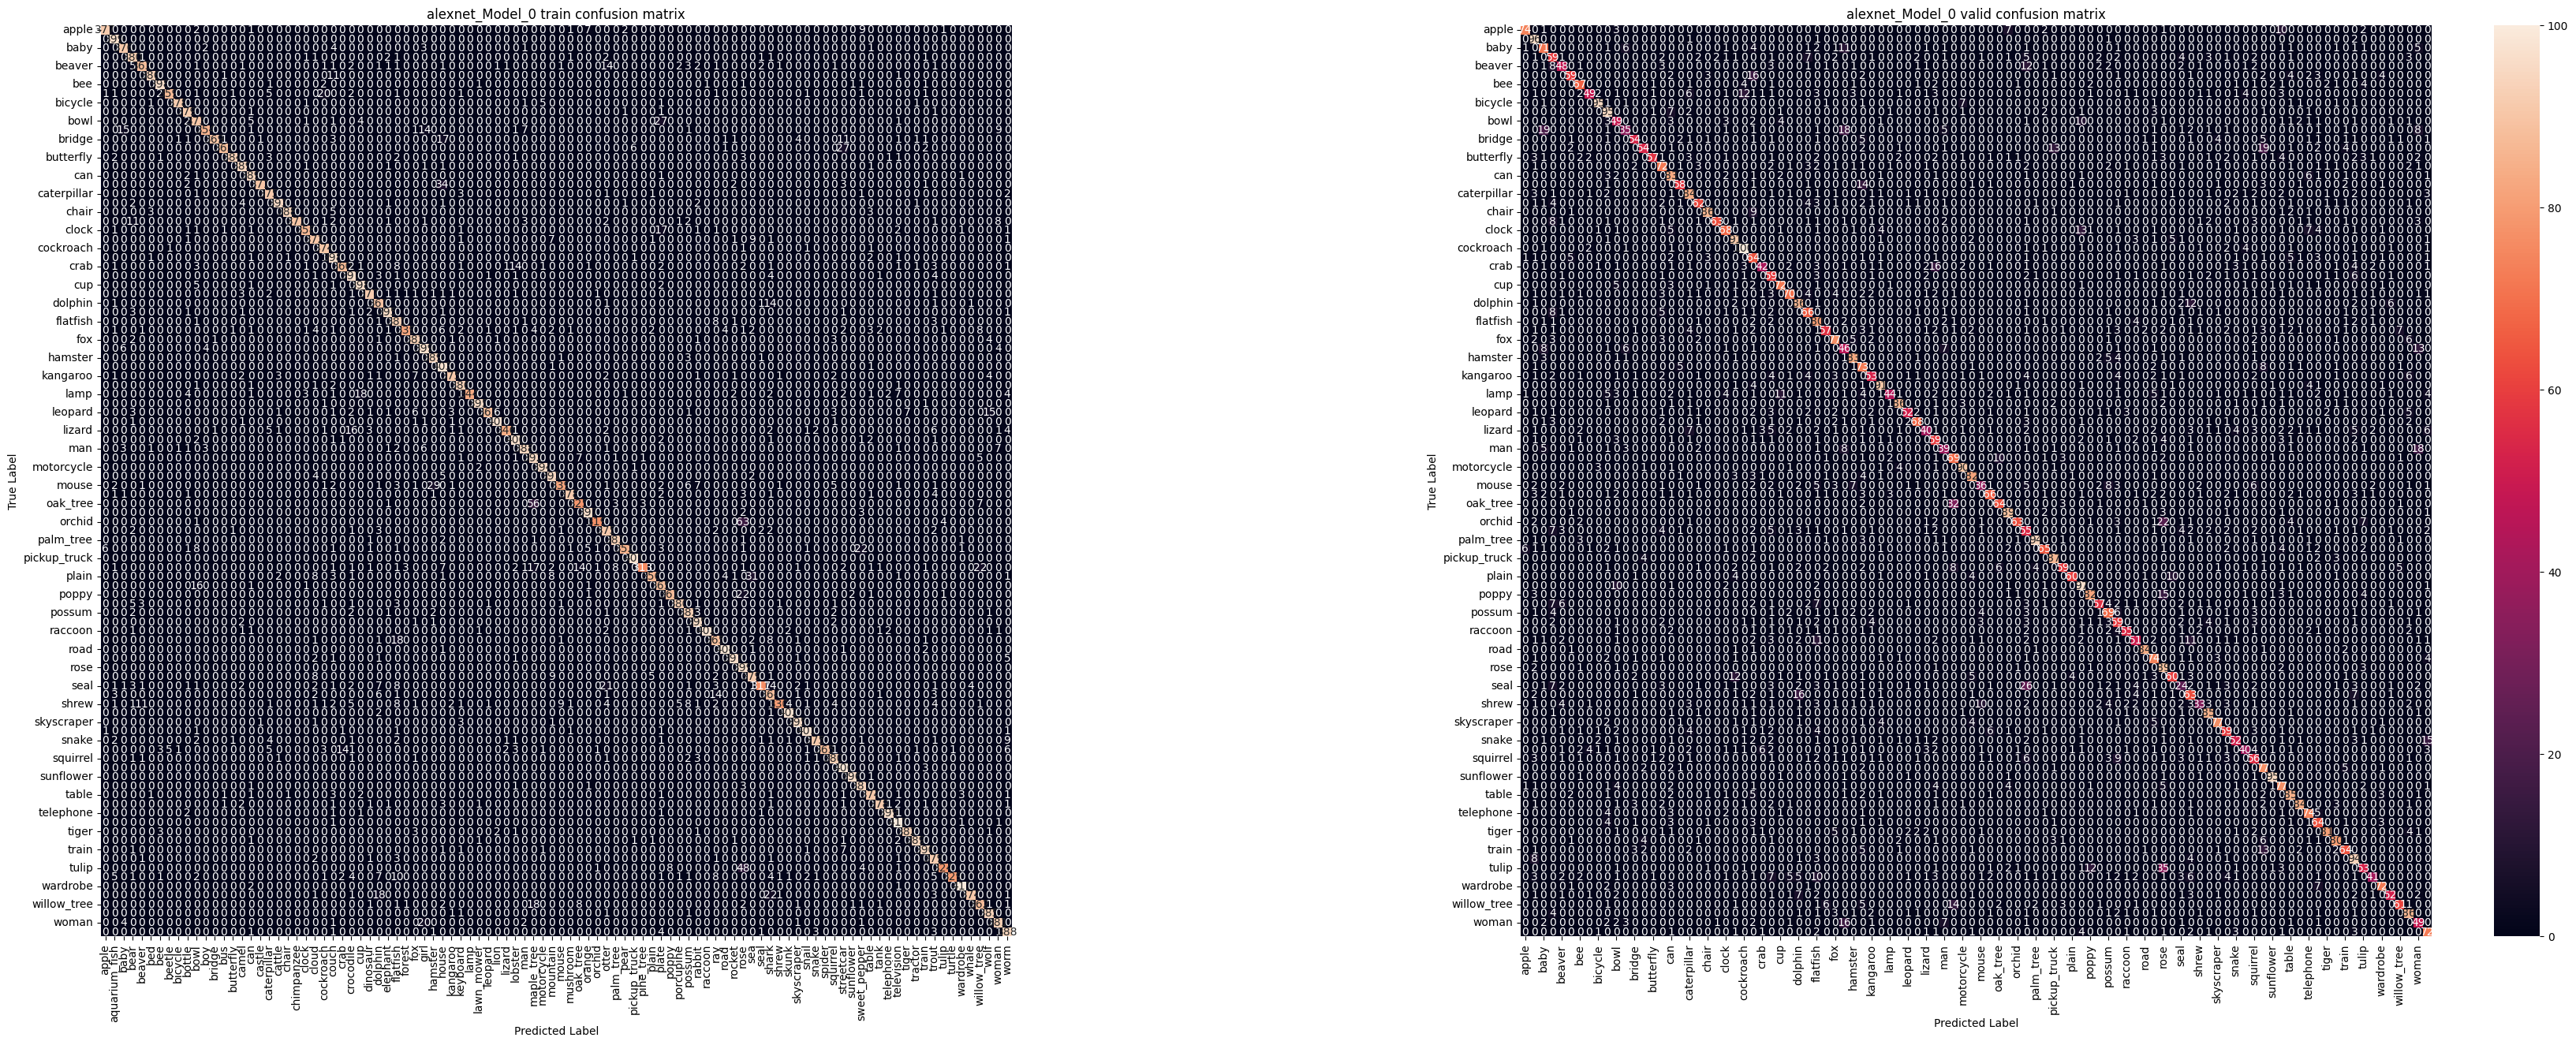

In [44]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

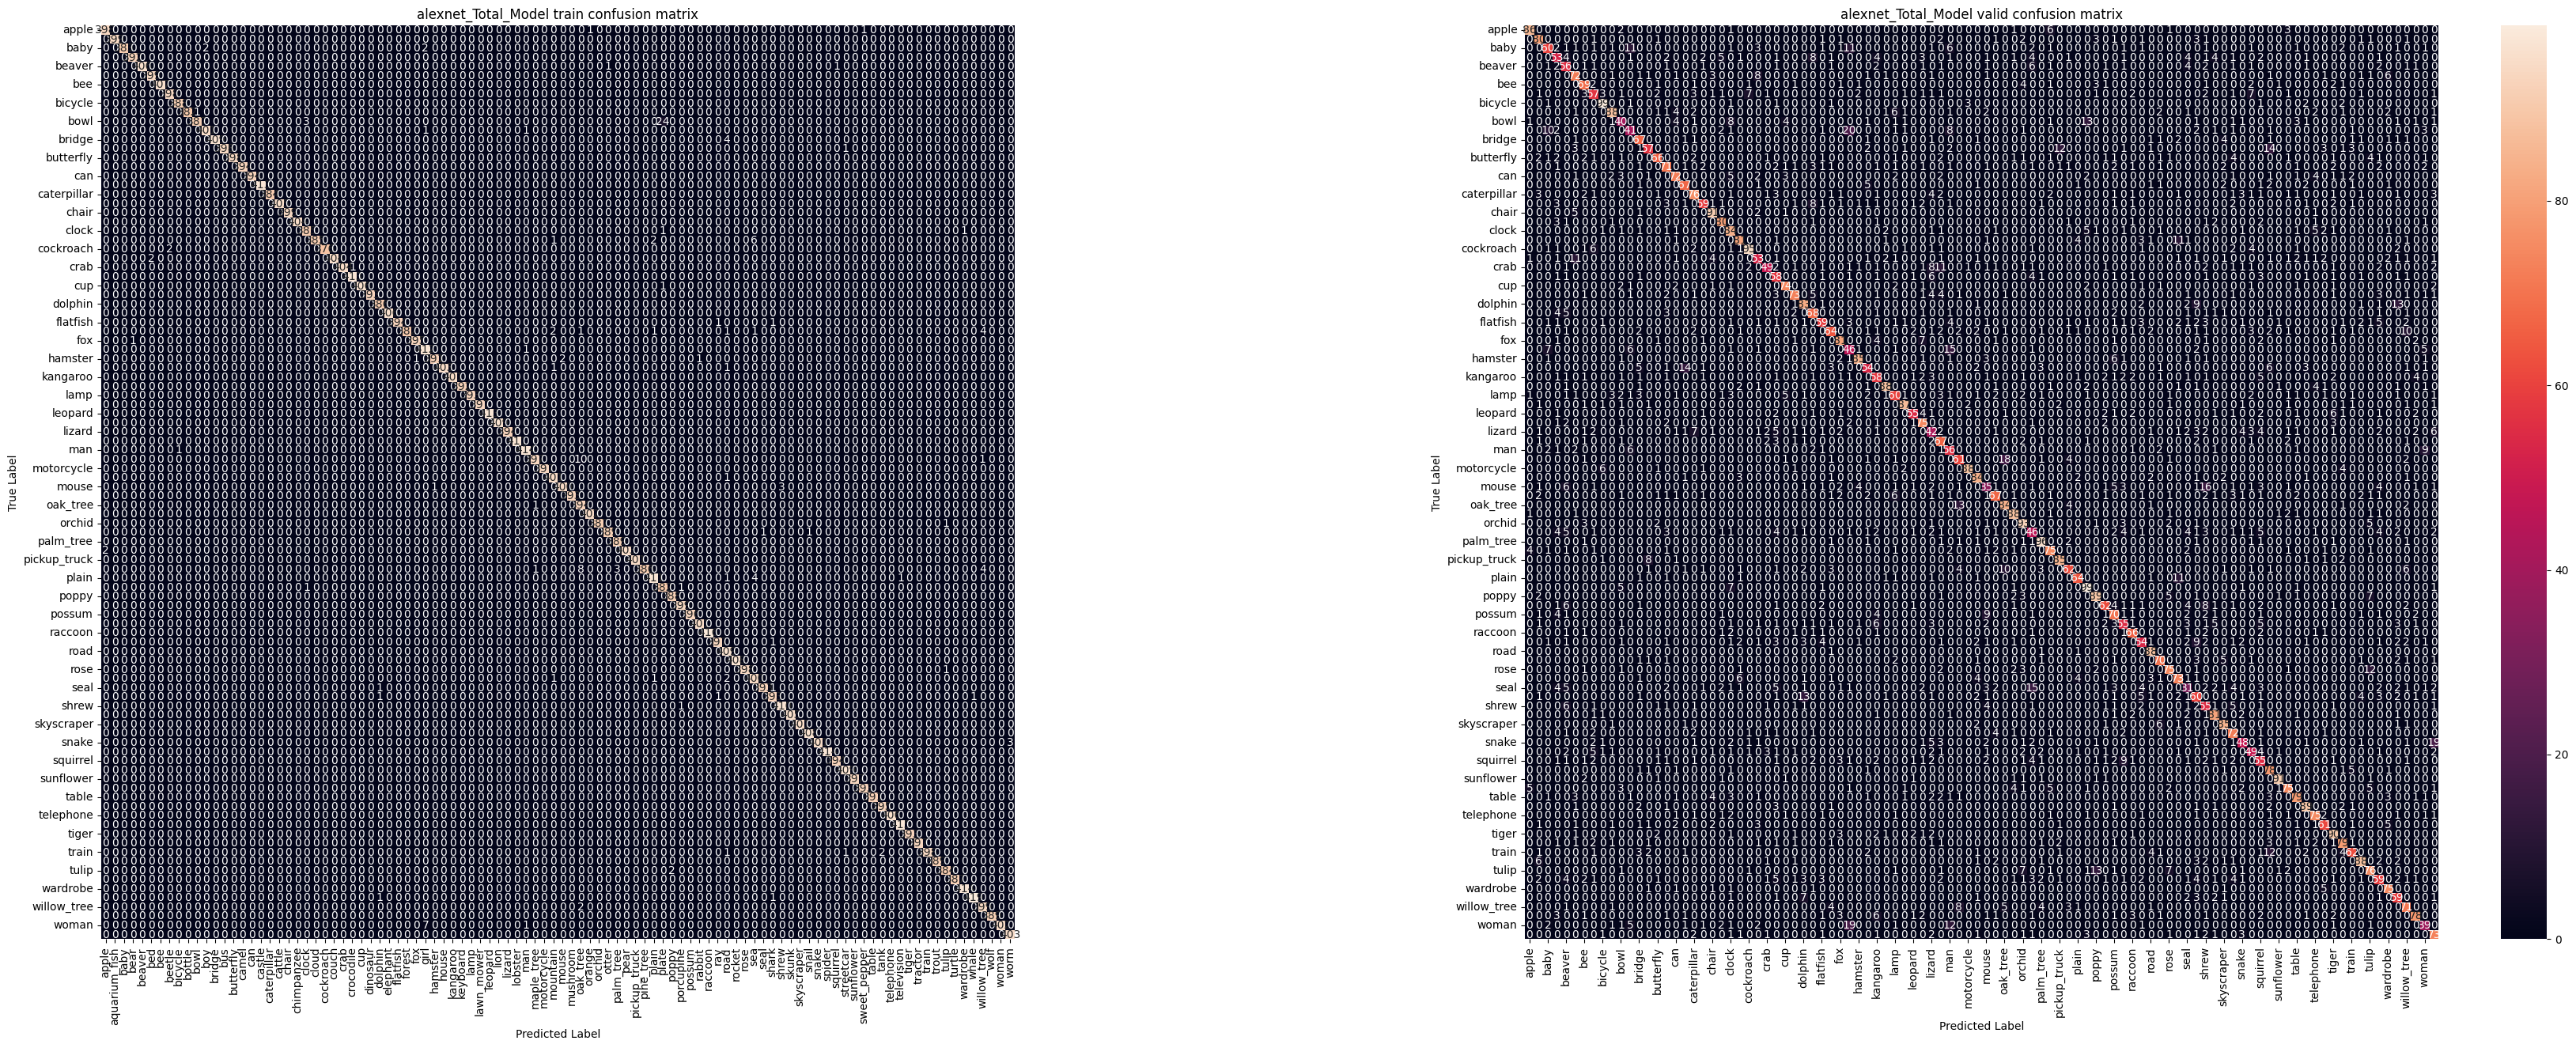

In [45]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

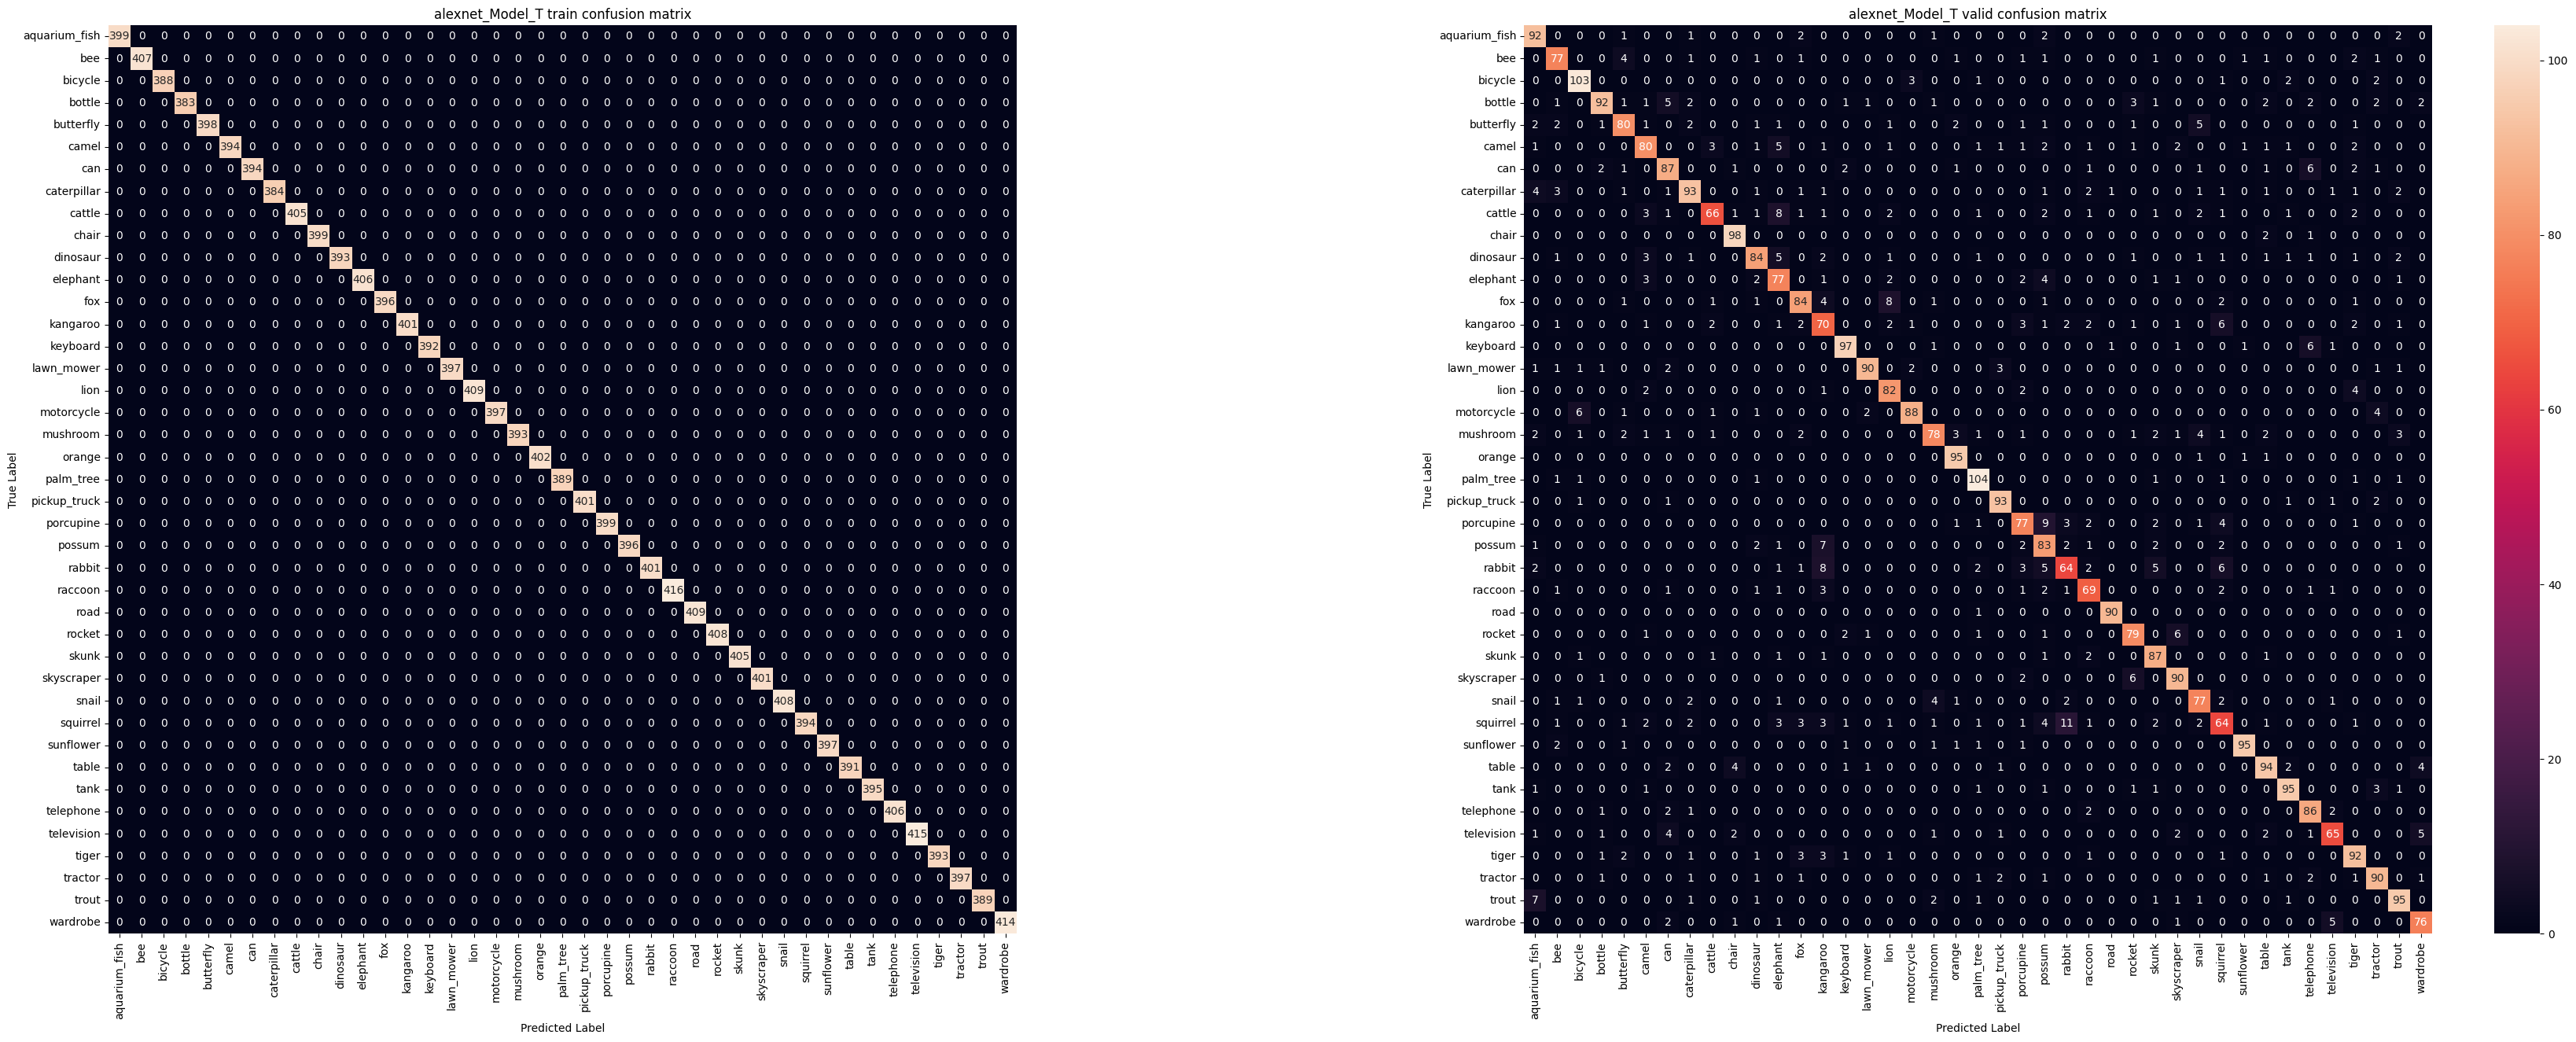

In [46]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

In [47]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [ ]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [ ]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,26022,34,34,29,34,0.999952,0.978841,0.999493,0.999998,True,False,True,False,False
1,30571,60,60,68,60,1.000000,0.696751,0.999967,1.000000,True,False,True,False,False
2,7464,94,84,94,94,0.504170,1.000000,0.999976,0.999997,False,True,True,True,True
3,38013,20,84,20,20,0.997985,1.000000,0.999999,0.997298,False,True,True,True,True
4,21038,89,58,89,89,1.000000,1.000000,1.000000,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,1326,85,37,85,85,0.796728,0.999999,0.996972,0.930009,False,True,True,True,True
39996,3959,30,30,1,30,0.999944,0.664909,0.998251,0.999995,True,False,True,False,False
39997,5372,67,67,10,67,0.999983,0.802514,0.999947,1.000000,True,False,True,False,False
39998,42293,77,77,7,77,1.000000,0.660767,1.000000,1.000000,True,False,True,False,False


In [ ]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
129,23543,15,17,15,15,0.969499,1.000000,0.999557,0.739429,False,True,True,True,True
163,18308,34,34,80,34,0.999961,0.676987,0.998123,0.873240,True,False,True,False,False
513,36663,7,79,7,7,0.868906,0.999993,0.999994,0.792507,False,True,True,True,True
590,39427,11,11,2,11,0.999996,0.998140,0.999263,0.886546,True,False,True,False,False
1086,34775,13,37,13,13,0.559988,0.999994,0.999987,0.672807,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38559,46719,91,55,91,91,0.434434,0.999738,0.998948,0.538741,False,True,True,True,True
38600,39355,67,67,28,67,0.999991,0.849836,0.999986,0.899924,True,False,True,False,False
38954,12471,50,65,50,50,0.624711,0.999924,0.999751,0.679760,False,True,True,False,True
39102,39020,85,17,85,85,0.990859,0.999910,0.988279,0.885598,False,True,True,True,True


In [ ]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
7171,231,90,12,90,90,0.577274,0.999991,0.993637,0.597869,False,True,True,False,True
12495,16621,33,33,94,33,0.999999,0.999978,0.984485,0.799105,True,False,True,True,False
14781,44490,13,81,13,13,0.895545,0.999925,0.991301,0.629142,False,True,True,False,True
22207,13034,55,55,27,55,0.999988,0.842548,0.996413,0.907477,True,False,True,True,False
23517,49306,64,66,64,64,0.891693,1.000000,0.995451,0.729708,False,True,True,False,True
24910,42999,28,82,28,28,0.508043,1.000000,0.999998,0.703894,False,True,True,False,True
26960,23417,90,30,90,90,0.735460,0.999994,0.999942,0.813844,False,True,True,False,True
34196,40448,10,61,10,10,0.999436,0.999982,0.999836,0.666650,False,True,True,False,True
34275,6726,84,84,5,84,0.999956,0.957108,0.977679,0.724241,True,False,True,True,False
38954,12471,50,65,50,50,0.624711,0.999924,0.999751,0.679760,False,True,True,False,True


In [ ]:
df_results[(df_results['Decision']==df_results['flag'])&(df_results['Softmax_decision']<0.9)&(df_results['Softmax_F']>df_results['Softmax_T'])&(df_results['Match_F']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
19910,39393,92,62,92,92,0.999998,0.999441,0.96894,0.803532,False,True,True,True,True


In [ ]:
df_results[(df_results['Match_T']!=True)&(df_results['Softmax_T']>0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,26022,34,34,29,34,0.999952,0.978841,0.999493,0.999998,True,False,True,False,False
8,23745,22,22,10,22,0.998434,0.996061,0.999960,0.999148,True,False,True,False,False
9,25156,58,58,89,58,1.000000,0.999996,0.999972,0.999997,True,False,True,False,False
18,30639,82,82,92,82,1.000000,0.999962,1.000000,1.000000,True,False,True,False,False
22,5428,54,54,70,54,0.999994,0.999785,0.999982,0.999833,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39982,12185,77,77,50,77,1.000000,0.992340,0.999999,0.999761,True,False,True,False,False
39988,22048,93,93,29,93,0.999927,0.990067,0.999999,0.999926,True,False,True,False,False
39989,29273,60,60,68,60,0.999973,0.999905,0.821528,0.999999,True,False,True,False,False
39991,33712,32,32,10,32,0.999991,0.996647,0.999997,0.999972,True,False,True,False,False


In [ ]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

90    2
33    1
13    1
55    1
64    1
28    1
10    1
84    1
50    1
Name: Target, dtype: int64

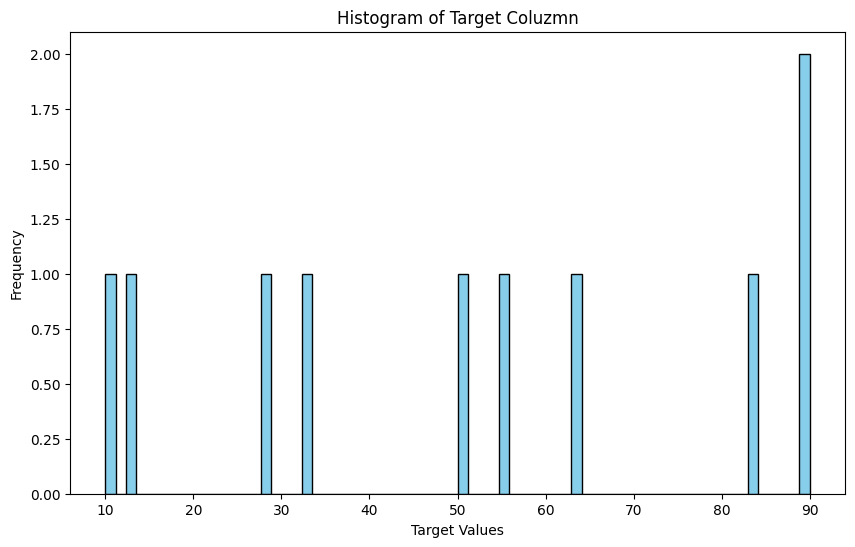

In [ ]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [ ]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,30937,87,84,94,94,0.523301,0.999651,0.999984,1.000000,False,False,False,True,True
1,418,96,96,85,96,0.721866,0.551565,0.863573,0.999992,True,False,True,False,False
2,12717,63,63,64,63,0.879194,0.916432,0.982399,0.999998,True,False,True,False,False
3,38981,14,35,91,91,0.290336,0.357593,0.414152,0.906667,False,False,False,True,True
4,39911,31,55,38,64,0.607895,0.480210,0.274695,0.786546,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,17329,28,22,28,28,0.428832,1.000000,0.999957,1.000000,False,True,True,True,True
9996,24377,83,57,10,57,0.948181,0.991344,0.583059,0.879850,False,False,False,False,False
9997,23817,91,84,91,91,0.406968,0.999873,0.999995,0.999978,False,True,True,True,True
9998,21705,28,11,28,28,0.973358,1.000000,1.000000,1.000000,False,True,True,True,True


In [ ]:
df_results_v[(df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
4,39911,31,55,38,64,0.607895,0.480210,0.274695,0.786546,False,False,False,False,True
19,38561,93,93,27,77,0.411895,0.821890,0.548362,0.693319,True,False,False,False,False
22,48705,88,78,29,34,0.452908,0.633664,0.840622,0.517799,False,False,False,False,False
25,30214,1,73,64,64,0.925314,0.995916,0.991700,0.638892,False,False,False,True,True
27,44722,14,62,14,14,0.998364,0.999902,0.710602,0.725943,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,4488,15,73,69,85,0.553385,0.716128,0.415739,0.860012,False,False,False,False,True
9976,16320,41,35,2,10,0.570829,0.690831,0.564989,0.650771,False,False,False,True,True
9988,32616,14,82,14,14,0.243616,0.999551,0.997106,0.794856,False,True,True,True,True
9991,43711,86,95,86,86,0.656338,0.881151,0.913452,0.577617,False,True,True,True,True


In [ ]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])&(df_results_v['Decision']==True)&(df_results_v['Match_F']==True)&(df_results_v['Match_T']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
17,34851,84,84,94,94,0.780839,1.000000,0.999946,0.971099,True,False,False,True,False
76,24952,98,98,46,46,0.999407,1.000000,0.998911,0.977165,True,False,False,True,False
84,907,54,54,6,54,0.974190,0.994366,0.912261,0.836579,True,False,True,True,False
168,32934,73,73,91,73,0.999973,0.999060,0.974167,0.692573,True,False,True,True,False
397,13263,77,77,80,77,0.973164,0.689512,0.999534,0.578474,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9856,15300,95,95,10,95,0.568480,0.987527,0.815562,0.640481,True,False,True,True,False
9936,21149,25,25,20,20,0.543899,0.977613,0.892437,0.726942,True,False,False,True,False
9944,7405,25,25,5,5,0.999997,0.839067,0.888804,0.998919,True,False,False,True,False
9957,14979,54,54,69,9,0.934670,0.922300,0.767553,0.909180,True,False,False,True,False


In [ ]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

2     46
80    40
46    39
50    38
44    36
      ..
60     2
43     2
94     2
96     1
52     1
Name: Target, Length: 99, dtype: int64

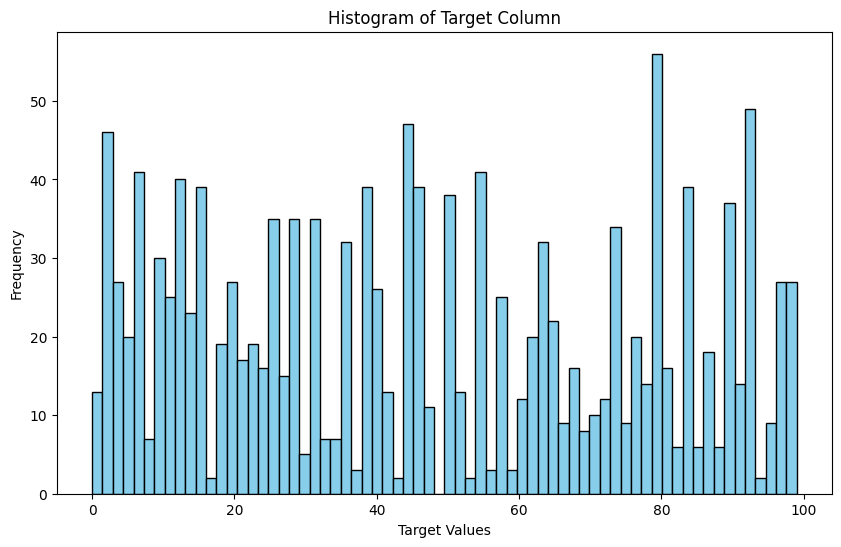

In [ ]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [ ]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(0.3697975143713906, 0.9861, 21620, 18380)

In [ ]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(5.1145044025421145, 0.6476, 4802, 5198)

In [ ]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            


            for d,t in zip(data,target):
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_d<0.9):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T


In [ ]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_train_loss,total_train_accu,sum_F,sum_T

(0.0029192791402172587, 0.99965, 22018, 17982)

In [ ]:

total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_valid_loss,total_valid_accu,sum_F,sum_T

(3.41537090215683, 0.6985, 5494, 4506)